# ⚽ 2026 월드컵 A조 최종전 스코어 예측 — 남아공 🇿🇦 vs 대한민국 🇰🇷

**기본 포아송(Poisson) + Dixon-Coles** 모델을 **단계별로** 따라가는 노트북입니다.
각 셀의 **출력**으로 중간 과정을 직접 확인할 수 있어요.

- **경기**: 2026-06-24, 몬테레이(과달루페, 멕시코) — **중립경기** → 홈 어드밴티지 = 0
- **데이터**: ① `martj42/international_results` (국제 A매치 결과) + ② `Dato-Futbol/fifa-ranking` (FIFA 랭킹 시계열)
- **흐름**: 데이터 적재 → 롱 포맷 변환 → 포아송 회귀 학습 → λ(기대득점) 계산 → 스코어 확률 행렬 → 예측 → 백테스트

> 모델 한 줄 요약: *과거 결과로 팀별 공격력·수비력을 추정하고, 두 팀의 기대득점 λ를 구해 모든 스코어의 확률을 계산한다.*

## 0. 준비 — 라이브러리와 설정값

In [1]:
import os, urllib.request
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import poisson
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.width", 120)

# ---- 핵심 설정값 (이 값들을 바꿔가며 실험해 보세요) ----
RESULTS_URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
FIFA_URL    = "https://raw.githubusercontent.com/Dato-Futbol/fifa-ranking/master/ranking_fifa_historical.csv"

HALF_LIFE_DAYS = 365 * 2       # 시간 감쇠 반감기(2년): 2년 전 경기는 가중치 0.5
WINDOW_START   = "2015-01-01"  # 학습 데이터 최소 시작일
MIN_MATCHES    = 12            # 표본이 적은 팀은 제외
FRIENDLY_W     = 0.5           # 친선경기 가중치(경쟁경기=1.0)
MAX_GOALS      = 10            # 스코어 행렬 크기 (0~10골)

HOME, AWAY = "South Africa", "South Korea"   # 픽스처상 home/away (예측은 중립)
AS_OF = pd.Timestamp("2026-06-24")           # 이 시점까지의 정보만으로 예측
BACKTEST_CUTOFF = pd.Timestamp("2025-08-01") # 백테스트: 이 이전=학습 / 이후=평가
print("설정 완료")

설정 완료


## 1단계. 국제 A매치 결과 불러오기

`martj42` 데이터셋(1872년~현재, 약 5만 경기)을 받아옵니다. 컬럼 구조를 확인하세요.

In [2]:
def ensure(path, url):
    if not os.path.exists(path):
        print("다운로드 중:", path)
        urllib.request.urlretrieve(url, path)
    return path

df = pd.read_csv(ensure("results.csv", RESULTS_URL), parse_dates=["date"])
df = df.dropna(subset=["home_score", "away_score"]).copy()   # 미래 픽스처(NA) 제거
df["home_score"] = df["home_score"].astype(int)
df["away_score"] = df["away_score"].astype(int)

print(f"총 {len(df):,} 경기   |   기간 {df.date.min().date()} ~ {df.date.max().date()}")
df.head()

총 49,445 경기   |   기간 1872-11-30 ~ 2026-06-21


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


### 예측할 경기가 데이터에 있는지 확인

이미 치러진 A조 경기들과, 우리가 맞출 **타깃 경기**(점수가 비어 있음)를 함께 봅니다.
타깃 경기는 `neutral=True`(중립) 인 점에 주목하세요.

In [3]:
full = pd.read_csv("results.csv", parse_dates=["date"])   # 픽스처 포함(NA 미제거) 버전
a_group = full[(full.tournament=="FIFA World Cup") & (full.date.dt.year==2026) &
               (full.home_team.isin([HOME,AWAY]) | full.away_team.isin([HOME,AWAY]))]
a_group[["date","home_team","away_team","home_score","away_score","city","country","neutral"]]

,date,home_team,away_team,home_score,away_score,city,country,neutral
49405,2026-06-11,Mexico,South Africa,2.0,0.0,Mexico City,Mexico,False
49406,2026-06-11,South Korea,Czech Republic,2.0,1.0,Zapopan,Mexico,True
49429,2026-06-18,Czech Republic,South Africa,1.0,1.0,Atlanta,United States,True
49430,2026-06-18,Mexico,South Korea,1.0,0.0,Zapopan,Mexico,False
49454,2026-06-24,South Africa,South Korea,NaN,NaN,Guadalupe,Mexico,True


- 한국은 데이터에서 **`South Korea`** 로 표기됩니다(나중에 FIFA 랭킹은 `Korea Republic` 이라 매핑이 필요).
- 마지막 줄 `2026-06-24 South Africa vs South Korea` 가 **우리가 예측할 경기**(점수 NaN).
- 한국은 체코전 승(2-1)·멕시코전 패(0-1), 남아공은 멕시코전 패(0-2)·체코전 무(1-1) → 이 **최신 폼이 학습에 반영**됩니다.

## (보조) FIFA 랭킹을 경기에 붙이기 — point-in-time merge

각 경기 **직전 시점**에 유효한 FIFA 랭킹 점수를 양 팀에 붙입니다. (미래 정보 누수 방지)
실무 함정 두 가지를 처리합니다: ① 팀명 불일치(`Korea Republic`→`South Korea`), ② 공개 랭킹 데이터가 **2024-09까지만** 존재.

In [4]:
FIFA_NAME_MAP = {"Korea Republic":"South Korea", "Korea DPR":"North Korea",
                 "USA":"United States", "China PR":"China", "IR Iran":"Iran",
                 "Cabo Verde":"Cape Verde"}

fr = pd.read_csv(ensure("fifa_rank.csv", FIFA_URL), parse_dates=["date"])
fr["team"] = fr["team"].replace(FIFA_NAME_MAP)
fr = fr[["team","date","total_points"]].sort_values("date")
print("FIFA 랭킹 데이터 기간:", fr.date.min().date(), "~", fr.date.max().date())

def join_side(side):   # 경기일 기준 가장 최근(backward) 랭킹을 붙임
    left = df[["date", f"{side}_team"]].rename(columns={f"{side}_team":"team"}).sort_values("date")
    return pd.merge_asof(left, fr, on="date", by="team", direction="backward")["total_points"].values

dfr = df.copy()
dfr["home_rank_pts"] = join_side("home")
dfr["away_rank_pts"] = join_side("away")
dfr["rank_diff"] = dfr["home_rank_pts"] - dfr["away_rank_pts"]

# 한국 경기 몇 개로 결과 확인
sample = dfr[(dfr.home_team=="South Korea")|(dfr.away_team=="South Korea")]
sample = sample.dropna(subset=["rank_diff"]).tail(5)
sample[["date","home_team","away_team","home_rank_pts","away_rank_pts","rank_diff"]]

FIFA 랭킹 데이터 기간: 1992-12-31 ~ 2024-09-19


,date,home_team,away_team,home_rank_pts,away_rank_pts,rank_diff
49218,2026-03-31,Austria,South Korea,1620.87,1137.47,483.40
49271,2026-05-30,South Korea,Trinidad and Tobago,1572.61,1213.25,359.36
49301,2026-06-03,South Korea,El Salvador,1759.95,1486.03,273.92
49406,2026-06-11,South Korea,Czech Republic,1572.61,1502.90,69.71
49430,2026-06-18,Mexico,South Korea,1502.90,1415.07,87.83


> **솔직한 한계**: 이 팀강도 포아송 모델에서 FIFA 랭킹은 사실 **상당 부분 중복**입니다(모델이 결과로 강도를 이미 추정). 랭킹은 *표본이 적은 약체팀*일 때 도움이 되고, 여기선 **교차검증용 컨텍스트**로 씁니다. `rank_diff` 를 공변량으로 넣고 싶으면 회귀식에 추가하면 됩니다.

In [5]:
# 참고: 현재(2026-06-11 발표, 월드컵 종료까지 고정) FIFA 랭킹
print("South Korea : 25위 (1591.6점)")
print("South Africa: 60위")
print("→ 랭킹 격차도 한국 우세를 시사 — 결과 기반 모델과 방향 일치")

South Korea : 25위 (1591.6점)
South Africa: 60위
→ 랭킹 격차도 한국 우세를 시사 — 결과 기반 모델과 방향 일치


## 2단계. 포아송 회귀용 '롱 포맷' 만들기  ← 핵심 개념

포아송 회귀는 **'한 팀이 한 경기에서 넣은 골 수'** 를 한 행으로 봅니다.
그래서 **경기 1건 → 2행**으로 펼칩니다:

| 행 | goals | team(공격) | opp(수비) | is_home |
|----|-------|-----------|----------|---------|
| 홈 득점 | 홈팀 골 | 홈팀 | 원정팀 | 1 (중립이면 0) |
| 원정 득점 | 원정팀 골 | 원정팀 | 홈팀 | 0 |

여기에 **가중치 w** = (시간 감쇠) × (친선경기 하향) 을 부여합니다.

In [6]:
def make_long(df, as_of):
    d = df[(df.date >= WINDOW_START) & (df.date <= as_of)].copy()
    # 가중치: 최근일수록 ↑, 친선경기는 ↓
    age = (as_of - d.date).dt.days
    xi = np.log(2) / HALF_LIFE_DAYS
    d["w"] = np.exp(-xi * age) * np.where(d.tournament.eq("Friendly"), FRIENDLY_W, 1.0)
    # 표본 적은 팀 제외 (양 팀 모두 기준 충족해야 사용)
    cnt = pd.concat([d.home_team, d.away_team]).value_counts()
    keep = set(cnt[cnt >= MIN_MATCHES].index)
    d = d[d.home_team.isin(keep) & d.away_team.isin(keep)].copy()
    # 경기 1건 -> 2행
    home = pd.DataFrame({"goals":d.home_score, "team":d.home_team, "opp":d.away_team,
                         "is_home":np.where(d.neutral,0,1), "w":d.w})
    away = pd.DataFrame({"goals":d.away_score, "team":d.away_team, "opp":d.home_team,
                         "is_home":0, "w":d.w})
    return pd.concat([home, away], ignore_index=True), d, keep

long, used, keep = make_long(df, AS_OF)
print(f"학습 경기 수: {len(used):,}  →  롱 포맷 행 수: {len(long):,}  (=경기×2)")
print(f"대상 팀 수(표본 {MIN_MATCHES}경기 이상): {len(keep)}")
long.head(6)

학습 경기 수: 10,823  →  롱 포맷 행 수: 21,646  (=경기×2)
대상 팀 수(표본 12경기 이상): 246


,goals,team,opp,is_home,w
0,1,Bahrain,Jordan,0,0.009366
1,1,Iran,Iraq,0,0.009366
2,2,South Korea,Saudi Arabia,0,0.009366
3,1,South Africa,Zambia,1,0.009366
4,4,China,Oman,0,0.009375
5,1,Cameroon,DR Congo,1,0.009393


- `team` = 골을 넣은 팀(공격력 추정), `opp` = 상대(수비력 추정), `w` = 가중치.
- 아래에서 가중치가 실제로 최근 경기에 더 큰 값을 주는지 확인합니다.

In [7]:
# 가중치 직관 확인: 오래된 경기일수록 w가 작아짐
chk = used[["date","tournament","w"]].copy()
chk["years_ago"] = ((AS_OF - chk.date).dt.days/365).round(1)
chk.sort_values("date").iloc[[0, len(chk)//2, -1]]

,date,tournament,w,years_ago
38414,2015-01-04,Friendly,0.009366,11.5
43963,2021-06-03,Friendly,0.086561,5.1
49444,2026-06-21,FIFA World Cup,0.997156,0.0


## 3단계. 포아송 회귀 학습

회귀식: **`goals ~ C(team) + C(opp) + is_home`**
- `C(team)` → 각 팀의 **공격력**, `C(opp)` → 각 팀의 **수비 실점 경향**, `is_home` → **홈 어드밴티지**
- 가중 최대우도(`freq_weights=w`)로 적합합니다.

In [8]:
def fit_poisson(long):
    m = smf.glm("goals ~ C(team) + C(opp) + is_home", data=long,
                family=sm.families.Poisson(), freq_weights=long["w"].values)
    return m.fit()

res = fit_poisson(long)
print(f"홈 어드밴티지 계수 exp = {np.exp(res.params['is_home']):.3f}  (홈팀 기대득점이 약 {(np.exp(res.params['is_home'])-1)*100:.0f}% 증가)")
print(f"적합된 파라미터 수: {len(res.params)}")

홈 어드밴티지 계수 exp = 1.258  (홈팀 기대득점이 약 26% 증가)
적합된 파라미터 수: 492


### 모델이 본 팀 강도 (해석 가능성 체크)

추정 계수에서 팀별 **공격력**과 **수비 실점 경향**을 뽑아봅니다.
- `attack` ↑ = 골을 더 많이 넣음(강한 공격)
- `defense_conceded` ↑ = 실점을 더 많이 함(약한 수비)

강팀이 상위에 오는지 보면 모델이 말이 되는지 감이 옵니다.

In [9]:
# 계수 이름에서 팀별 공격/수비 효과 추출
attack, defense = {}, {}
for name, val in res.params.items():
    if name.startswith("C(team)[T."):  attack[name[10:-1]]  = val
    elif name.startswith("C(opp)[T."):  defense[name[9:-1]] = val

strength = pd.DataFrame({"attack": pd.Series(attack),
                         "defense_conceded": pd.Series(defense)}).reindex(sorted(keep)).fillna(0.0)

print("◆ 이번 경기 두 팀:")
display(strength.loc[[HOME, AWAY]].round(3))
print("◆ 공격력 상위 8개팀 (sanity check):")
strength.sort_values("attack", ascending=False).head(8).round(3)

◆ 이번 경기 두 팀:


,attack,defense_conceded
South Africa,1.217,-0.770
South Korea,1.555,-0.967


◆ 공격력 상위 8개팀 (sanity check):


,attack,defense_conceded
Spain,2.235,-1.550
Germany,2.179,-1.153
Netherlands,2.103,-1.190
Portugal,2.092,-1.347
Brazil,2.073,-1.418
France,2.069,-1.405
Argentina,2.045,-1.852
England,2.042,-1.578


### 🔎 Feature Importance — 어떤 피처가 예측을 좌우하나?

이 모델은 **포아송 GLM**이라 트리 모델의 `feature_importances_`가 없습니다. 대신 **로그링크 선형모델**이므로 **계수의 크기(|coef|)가 곧 기대득점 λ에 대한 영향력 = 중요도**입니다.

- **왼쪽**: 피처 *유형*별 중요도(계수 표준편차). 공격력·수비력·홈 어드밴티지 중 무엇이 예측을 더 많이 가르는지.
- **오른쪽**: 개별 피처(팀별 공격/수비 효과) 중요도 상위 15개. 이번 경기 두 팀은 **테두리**로 강조.

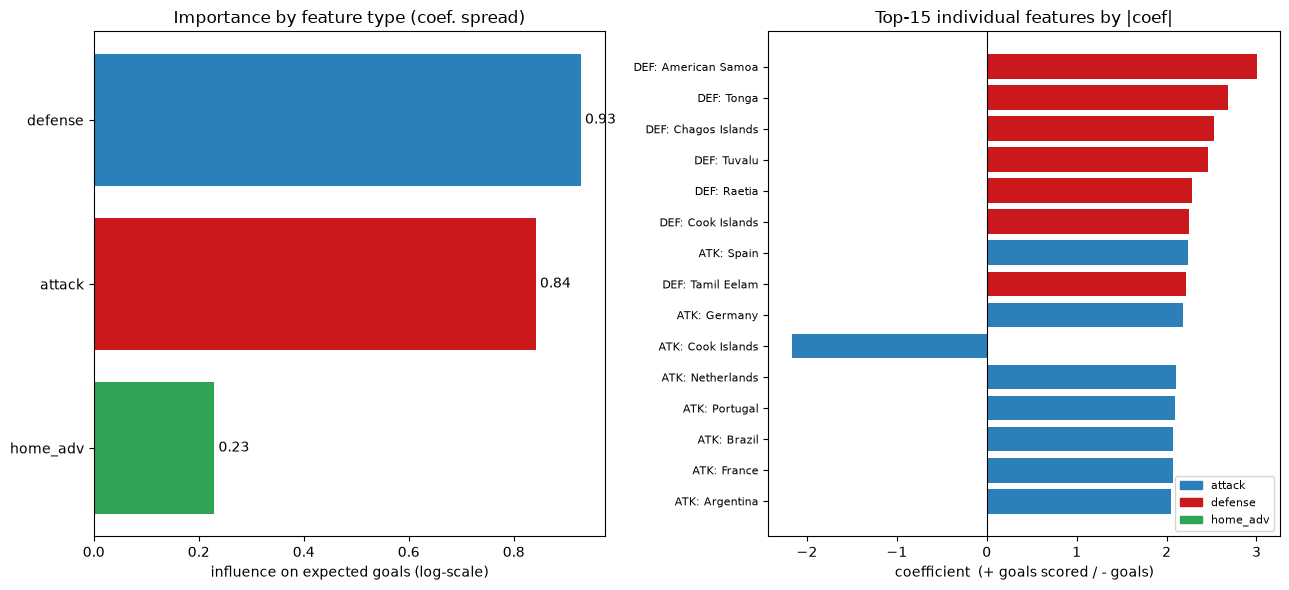

해석: attack 계수 ↑ = 강한 공격 / defense 계수 ↓(음수) = 강한 수비(실점 적음)
  South Africa : attack +1.22, defense -0.77
  South Korea  : attack +1.56, defense -0.97


In [10]:
# 📊 Feature Importance — 포아송 회귀 '계수' 기반
# 이 모델엔 트리 모델의 feature_importances_ 가 없습니다. 대신 로그링크 선형모델이라
# |계수| 자체가 곧 기대득점(λ)에 대한 영향력 = 피처 중요도입니다.
# 피처 종류: ① 팀 공격력 C(team)  ② 팀 수비력 C(opp)  ③ 홈 어드밴티지 is_home

imp = res.params.drop("Intercept").to_frame("coef")
imp["abs"]  = imp["coef"].abs()
imp["type"] = np.where(imp.index.str.startswith("C(team)"), "attack",
              np.where(imp.index.str.startswith("C(opp)"),  "defense", "home_adv"))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# (A) 피처 '유형'별 중요도: 계수의 표준편차 = 팀 간 변별력(예측을 얼마나 좌우하나)
#     is_home 은 단일 계수라 std가 없으므로 |계수| 값을 사용.
type_imp = pd.Series({
    "attack":   imp.loc[imp.type == "attack",  "coef"].std(),
    "defense":  imp.loc[imp.type == "defense", "coef"].std(),
    "home_adv": abs(res.params["is_home"]),
}).sort_values()
axes[0].barh(type_imp.index, type_imp.values, color=["#31a354", "#cb181d", "#2c7fb8"])
for i, v in enumerate(type_imp.values):
    axes[0].text(v, i, f" {v:.2f}", va="center")
axes[0].set_title("Importance by feature type (coef. spread)")
axes[0].set_xlabel("influence on expected goals (log-scale)")

# (B) '개별' 피처 중요도 상위 15 (팀별 공격/수비 효과). 이번 경기 두 팀은 테두리 강조.
top = imp.sort_values("abs", ascending=False).head(15).iloc[::-1]
def pretty(n):
    return n.replace("C(team)[T.", "ATK: ").replace("C(opp)[T.", "DEF: ").rstrip("]")
colors = np.where(top.type == "attack", "#2c7fb8",
         np.where(top.type == "defense", "#cb181d", "#31a354"))
edge = ["black" if (HOME in n or AWAY in n) else "none" for n in top.index]
axes[1].barh(range(len(top)), top["coef"], color=colors, edgecolor=edge, linewidth=1.5)
axes[1].set_yticks(range(len(top)))
axes[1].set_yticklabels([pretty(n) for n in top.index], fontsize=8)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Top-15 individual features by |coef|")
axes[1].set_xlabel("coefficient  (+ goals scored / - goals)")

from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color="#2c7fb8", label="attack"),
                        Patch(color="#cb181d", label="defense"),
                        Patch(color="#31a354", label="home_adv")],
               fontsize=8, loc="lower right")

plt.tight_layout(); plt.show()

# 이번 경기 두 팀의 피처 값 요약
print("해석: attack 계수 ↑ = 강한 공격 / defense 계수 ↓(음수) = 강한 수비(실점 적음)")
print(f"  {HOME:<13}: attack {strength.loc[HOME,'attack']:+.2f}, defense {strength.loc[HOME,'defense_conceded']:+.2f}")
print(f"  {AWAY:<13}: attack {strength.loc[AWAY,'attack']:+.2f}, defense {strength.loc[AWAY,'defense_conceded']:+.2f}")

### Dixon-Coles 보정 계수 ρ 추정

독립 포아송은 0-0, 1-1 같은 **저득점 무승부를 과소평가**합니다.
Dixon-Coles는 4개 칸(0:0, 1:0, 0:1, 1:1)에 보정항 τ를 곱하는데, 그 강도 ρ를 데이터에서 추정합니다.

In [11]:
def estimate_rho(d, res):
    lam = res.predict(pd.DataFrame({"team":d.home_team,"opp":d.away_team,
                                    "is_home":np.where(d.neutral,0,1)})).values
    mu  = res.predict(pd.DataFrame({"team":d.away_team,"opp":d.home_team,
                                    "is_home":np.zeros(len(d))})).values
    hs, as_, w = d.home_score.values, d.away_score.values, d.w.values
    m00,m01 = (hs==0)&(as_==0),(hs==0)&(as_==1)
    m10,m11 = (hs==1)&(as_==0),(hs==1)&(as_==1)
    def negll(rho):
        tau = np.ones(len(d))
        tau[m00]=1-lam[m00]*mu[m00]*rho; tau[m01]=1+lam[m01]*rho
        tau[m10]=1+mu[m10]*rho;          tau[m11]=1-rho
        return -np.sum(w*np.log(np.clip(tau,1e-9,None)))
    return minimize_scalar(negll, bounds=(-0.2,0.2), method="bounded").x

rho = estimate_rho(used, res)
print(f"추정된 ρ = {rho:+.3f}  (음수 → 저득점 무승부 확률을 살짝 끌어올림)")

추정된 ρ = -0.051  (음수 → 저득점 무승부 확률을 살짝 끌어올림)


## 4단계. 이번 경기 예측 — 먼저 λ(기대득점)

**중립경기**이므로 양 팀 모두 `is_home=0` 으로 둡니다.
- λ_남아공 = (남아공 공격력) vs (한국 수비) 로 계산
- λ_한국 = (한국 공격력) vs (남아공 수비) 로 계산

In [12]:
def dc_tau(x, y, lam, mu, rho):
    if x==0 and y==0: return 1 - lam*mu*rho
    if x==0 and y==1: return 1 + lam*rho
    if x==1 and y==0: return 1 + mu*rho
    if x==1 and y==1: return 1 - rho
    return 1.0

def score_matrix(lam, mu, rho):
    i = np.arange(MAX_GOALS+1)
    P = np.outer(poisson.pmf(i,lam), poisson.pmf(i,mu))
    for x in (0,1):
        for y in (0,1):
            P[x,y] *= dc_tau(x,y,lam,mu,rho)
    return P / P.sum()

# 중립경기(is_home=0)에서 양 팀 기대득점
lam = res.predict(pd.DataFrame({"team":[HOME],"opp":[AWAY],"is_home":[0]}))[0]   # 남아공
mu  = res.predict(pd.DataFrame({"team":[AWAY],"opp":[HOME],"is_home":[0]}))[0]   # 한국
print(f"λ(기대득점)   {HOME}: {lam:.3f}    {AWAY}: {mu:.3f}")

λ(기대득점)   South Africa: 0.791    South Korea: 1.351


### 스코어 확률 행렬

두 λ로 각 팀 득점의 포아송 확률을 만들고, 곱해서(+DC 보정) **모든 스코어의 확률**을 얻습니다.
표의 (행 i, 열 j) = `남아공 i골, 한국 j골`일 확률(%).

In [13]:
P = score_matrix(lam, mu, rho)
g = 6
mat = pd.DataFrame((P[:g+1,:g+1]*100).round(1),
                   index=[f"{HOME} {i}" for i in range(g+1)],
                   columns=[f"{AWAY} {j}" for j in range(g+1)])
mat

,South Korea 0,South Korea 1,South Korea 2,South Korea 3,South Korea 4,South Korea 5,South Korea 6
South Africa 0,12.4,15.2,10.7,4.8,1.6,0.4,0.1
South Africa 1,8.6,13.2,8.5,3.8,1.3,0.3,0.1
South Africa 2,3.7,5.0,3.4,1.5,0.5,0.1,0.0
South Africa 3,1.0,1.3,0.9,0.4,0.1,0.0,0.0
South Africa 4,0.2,0.3,0.2,0.1,0.0,0.0,0.0
South Africa 5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
South Africa 6,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 최종 요약 — 승/무/패, 최빈 스코어, Over/Under

In [14]:
gA = np.arange(P.shape[0])
hwin, draw, awin = np.tril(P,-1).sum(), np.trace(P), np.triu(P,1).sum()  # 행>열=남아공 우세
idx = np.unravel_index(np.argmax(P), P.shape)
eh, ea = (P.sum(1)*gA).sum(), (P.sum(0)*gA).sum()
over25 = sum(P[x,y] for x in gA for y in gA if x+y>=3)
btts   = P[1:,1:].sum()

print(f"기대득점     : {HOME} {eh:.2f}  -  {ea:.2f} {AWAY}")
print(f"승/무/패     : {HOME} {hwin*100:4.1f}%  |  무 {draw*100:4.1f}%  |  {AWAY} {awin*100:4.1f}%")
print(f"최빈 스코어  : {HOME} {idx[0]}-{idx[1]} {AWAY}  ({P[idx]*100:.1f}%)")
print(f"Over 2.5     : {over25*100:.1f}%      양팀득점(BTTS): {btts*100:.1f}%")
print("\n상위 스코어라인:")
flat = sorted([((x,y),P[x,y]) for x in gA for y in gA], key=lambda t:-t[1])[:6]
for (x,y),p in flat:
    print(f"   {HOME} {x}-{y} {AWAY} : {p*100:4.1f}%")

기대득점     : South Africa 0.79  -  1.35 South Korea
승/무/패     : South Africa 21.3%  |  무 29.4%  |  South Korea 49.4%
최빈 스코어  : South Africa 0-1 South Korea  (15.2%)
Over 2.5     : 36.2%      양팀득점(BTTS): 41.2%

상위 스코어라인:
   South Africa 0-1 South Korea : 15.2%
   South Africa 1-1 South Korea : 13.2%
   South Africa 0-0 South Korea : 12.4%
   South Africa 0-2 South Korea : 10.7%
   South Africa 1-0 South Korea :  8.6%
   South Africa 1-2 South Korea :  8.5%


### 시각화 — 스코어 히트맵 & 승무패 막대

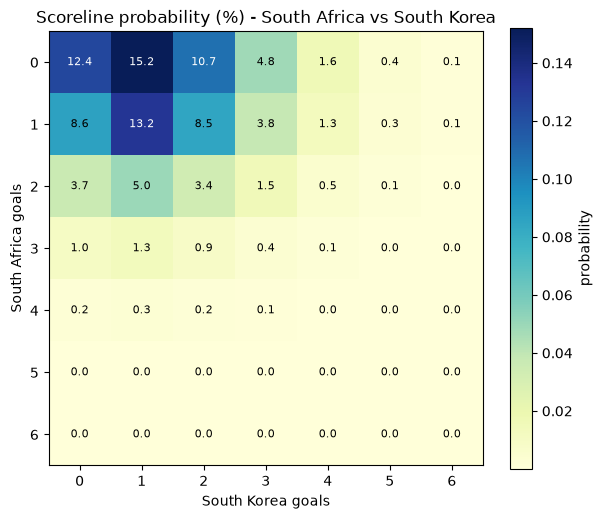

In [15]:
fig, ax = plt.subplots(figsize=(6.2,5.2))
M = P[:g+1,:g+1]
im = ax.imshow(M, cmap="YlGnBu", origin="upper")
for x in range(g+1):
    for y in range(g+1):
        ax.text(y, x, f"{M[x,y]*100:.1f}", ha="center", va="center",
                fontsize=8, color="black" if M[x,y] < M.max()*0.6 else "white")
ax.set_xticks(range(g+1)); ax.set_yticks(range(g+1))
ax.set_xlabel(f"{AWAY} goals"); ax.set_ylabel(f"{HOME} goals")
ax.set_title(f"Scoreline probability (%) - {HOME} vs {AWAY}")
fig.colorbar(im, label="probability"); plt.tight_layout(); plt.show()

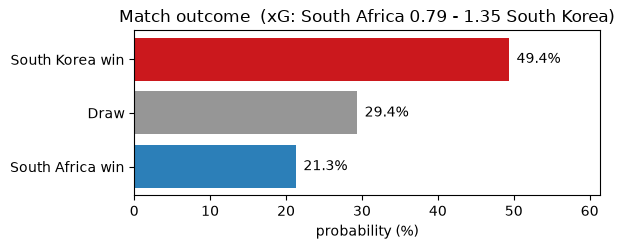

In [16]:
probs = np.array([hwin, draw, awin])
fig, ax = plt.subplots(figsize=(6.2,2.6))
bars = ax.barh([f"{HOME} win","Draw",f"{AWAY} win"], probs*100,
               color=["#2c7fb8","#969696","#cb181d"])
for b,v in zip(bars, probs*100):
    ax.text(v+1, b.get_y()+b.get_height()/2, f"{v:.1f}%", va="center")
ax.set_xlim(0, max(probs*100)+12); ax.set_xlabel("probability (%)")
ax.set_title(f"Match outcome  (xG: {HOME} {lam:.2f} - {mu:.2f} {AWAY})")
plt.tight_layout(); plt.show()

## 5단계. 모델 성능 평가 — 시간순 백테스트

**중요**: 이건 국가대표 모델이라 **클럽 리그(EPL·K리그) 경기는 테스트로 쓸 수 없습니다**(팀이 다름).
대신 **과거 국제 A매치 + 2026 월드컵 기 치러진 경기**로 평가합니다.

- 학습: `2025-08-01` 이전 / 평가: 그 이후
- 지표: 정확도(승무패), **log-loss**, **Brier**(확률 예측 품질). 단순 기저확률보다 낮으면 모델이 정보를 더한 것.

In [17]:
def predict_match(res, rho, home, away, neutral, keep):
    if home not in keep or away not in keep: return None
    hh = 0 if neutral else 1
    lam = res.predict(pd.DataFrame({"team":[home],"opp":[away],"is_home":[hh]}))[0]
    mu  = res.predict(pd.DataFrame({"team":[away],"opp":[home],"is_home":[0]}))[0]
    P = score_matrix(lam, mu, rho)
    return np.array([np.tril(P,-1).sum(), np.trace(P), np.triu(P,1).sum()])

# 학습(cutoff 이전)
tr = df[df.date < BACKTEST_CUTOFF]
long_tr, used_tr, keep_tr = make_long(tr, BACKTEST_CUTOFF)
res_tr = fit_poisson(long_tr)
rho_tr = estimate_rho(used_tr, res_tr)

# 평가(cutoff 이후)
te = df[(df.date >= BACKTEST_CUTOFF) & (df.date <= AS_OF)]
rows = []
for _, r in te.iterrows():
    p = predict_match(res_tr, rho_tr, r.home_team, r.away_team, bool(r.neutral), keep_tr)
    if p is None: continue
    actual = 0 if r.home_score>r.away_score else (1 if r.home_score==r.away_score else 2)
    rows.append((p, actual, r.tournament))

def metrics(rs):
    Pm = np.clip(np.array([x[0] for x in rs]), 1e-12, 1)
    y  = np.array([x[1] for x in rs]); oh = np.eye(3)[y]
    return (Pm.argmax(1)==y).mean(), -np.log(Pm[np.arange(len(y)),y]).mean(), ((Pm-oh)**2).sum(1).mean(), len(rs)

acc, ll, br, n = metrics(rows)
base = used_tr[["home_score","away_score"]]
p_base = np.array([(base.home_score>base.away_score).mean(),(base.home_score==base.away_score).mean(),(base.home_score<base.away_score).mean()])
base_ll = -np.log(np.clip(p_base[[x[1] for x in rows]],1e-12,1)).mean()

print(f"전체 국제경기 {n}경기 :  정확도 {acc*100:4.1f}%  |  log-loss {ll:.3f}  |  Brier {br:.3f}")
print(f"   (참고) 단순 기저확률 log-loss {base_ll:.3f}  ← 모델이 이보다 낮으면 정보 추가 성공")
wc = [x for x in rows if x[2]=="FIFA World Cup"]
if wc:
    a,l,b,m = metrics(wc)
    print(f"2026 월드컵 {m}경기   :  정확도 {a*100:4.1f}%  |  log-loss {l:.3f}  |  Brier {b:.3f}")
print("\n* 무승부는 본질적으로 가장 안 맞는 결과 → 3분류 정확도 50%대면 정상(무작위 33%)")
print("* 학습을 cutoff에 고정한 보수적 추정 → 매 라운드 재학습(walk-forward) 시 향상 여지")

전체 국제경기 921경기 :  정확도 60.0%  |  log-loss 0.835  |  Brier 0.490
   (참고) 단순 기저확률 log-loss 1.052  ← 모델이 이보다 낮으면 정보 추가 성공
2026 월드컵 40경기   :  정확도 57.5%  |  log-loss 0.929  |  Brier 0.575

* 무승부는 본질적으로 가장 안 맞는 결과 → 3분류 정확도 50%대면 정상(무작위 33%)
* 학습을 cutoff에 고정한 보수적 추정 → 매 라운드 재학습(walk-forward) 시 향상 여지


## 마무리 — 직접 실험해 볼 노브 & 다음 단계

**셀 맨 위 설정값을 바꾸고 전체 재실행**하면서 백테스트 `log-loss`가 줄어드는 방향으로 튜닝해 보세요.

- `HALF_LIFE_DAYS` ↓ → 최근 경기에 더 민감 / ↑ → 더 안정적
- `FRIENDLY_W` → 친선경기를 얼마나 믿을지
- `MIN_MATCHES`, `WINDOW_START` → 학습 표본 범위

**다음 단계 아이디어**
1. `rank_diff`(FIFA 랭킹 차)를 회귀식에 공변량으로 추가 → `goals ~ C(team)+C(opp)+is_home+rank_diff`
2. **xG**, 휴식일, 핵심 선수 출전 여부를 피처로
3. 승무패만 따로 **LightGBM**으로 만들어 포아송과 비교
4. λ로 **몬테카를로 시뮬레이션** → 조 통과 확률까지 계산

> ⚠️ 이 모델이 못 보는 변수: **남아공은 반드시 이겨야 하는 상황(동기부여)** — 통계 밖 요인이라 실제 경기엔 영향을 줄 수 있습니다.